<a href="https://colab.research.google.com/github/Nemipatel210/DataManagement/blob/main/DataManagment_PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌽 Iowa Corn: Production, Sales and August Weather

Why Iowa: https://www.caliper.com/featured-maps/maptitude-national-farmers-day-october-12-map.html?srsltid=AU7gw4U05tlWbcClT8-yBN4YarILnzDniH9BKny2hdmUYe2nfSr_Sqvg

Why focus on corn:  Iowa is the undisputed number-one corn-producing state in the U.S. (National Share: ~16.3%)



## Project question
> How have corn production and sales changed across Iowa counties over the Census of Agriculture years (1997–2022), and how do they line up with weather (temperature, precipitation, drought index)?

## The four corn measures (USDA NASS Census of Agriculture, county level)
| Data item | Short name used here | Unit |
|---|---|---|
| CORN - OPERATIONS WITH SALES | `operations_with_sales` | number of farms |
| CORN - SALES, MEASURED IN \$ | `sales_usd` | dollars |
| CORN, GRAIN - PRODUCTION, MEASURED IN BU | `grain_bu` | bushels |
| CORN, SILAGE - PRODUCTION, MEASURED IN TONS | `silage_tons` | tons |

## Datasets (3 different formats)
| # | Format | Content | Grain of the data |
|---|---|---|---|
| 1 | **CSV** | corn census data | county × census year × data item |
| 2 | **CSV** | Iowa August Palmer Drought Severity Index (PDSI) | one value per August |
| 3 | **XML** | Iowa August average temperature (°F) | one value per August |
| 4 | **JSON** | Iowa August precipitation (inches) | one value per August |

## Dataset Links:
1. https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/county/time-series

2. https://quickstats.nass.usda.gov/

## Keyword:
Bushel : A bushel is a traditional unit of measurement for the volume of dry commodities (approximately 35.24 liters )

Corn Silage: A high-moisture livestock feed made by chopping the entire corn plant (stalk, leaves, and grain) while it is still green and fermenting it in airtight storage.

Corn Grain: The dry, individual kernels stripped from the cob during harvest, used globally for animal feed, ethanol production, and human food.


# Step 1: Reading the data

In [1]:
#---------------------------SETUP----------------------------------
import time, os, sys, re #basics
import zipfile, json, datetime, string   #string for annotating points in scatter
import numpy as np #basic math
from statistics import * #stats

import matplotlib.pyplot as plt #import pylab as plt #apparently discouraged now:
 #https://stackoverflow.com/questions/11469336/what-is-the-difference-between-pylab-and-pyplot
 #https://www.tutorialspoint.com/matplotlib/matplotlib_pylab_module.htm

import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler
#s4 = Styler(df4, uuid_len=0, cell_ids=False)

import missingno as msno

from google.colab import files

#import webbrowser

import seaborn as sns

from google.colab import data_table
data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
data_table.max_columns = 50
#!and may have to click at top right spreadsheet icon

#many tricks how to extend notebook functionality
#https://coderzcolumn.com/tutorials/python/list-of-useful-magic-commands-in-jupyter-notebook-lab
#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#MAGICS and THEMES/STYLES: important! does affect not just shading/colors, but also fonts, spacing, etc
#(even if you only select default (v not selecting anything) [but does seem to work better if you do make explicit sleections])

###magics: https://ipython.readthedocs.io/en/stable/interactive/magics.html
#most essential setup for vis: it does affect vis! careful!! stick with inline, maybe notebook; others mostly for non-notebook, eg spyder environ
#https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html recomends *inline*!
#show current one:
#%matplotlib
#%matplotlib --list
#interactive plots:
#%matplotlib notebook
#static images of your plot:
%matplotlib inline
#may play with this one and other magics (btw default is probably agg)
#%matplotlib nbagg
##https://www.marktechpost.com/2023/10/20/6-magic-commands-for-jupyter-notebooks-in-python-data-science/
#%%latex
#%ai
#%run
#%writefile
#%history -n

###themes/styles: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
#https://jakevdp.github.io/PythonDataScienceHandbook/04.11-settings-and-stylesheets.html
#https://matplotlib.org/stable/tutorials/introductory/customizing.html
#here more about art and style than under the hood functionality as with magics, explore and experiment
#many may find 'default' or seaborn ones more pleasing; my fav 'classic' is back from 90s ;)
#plt.style.available #list available styles :) may install more
#plt.style.use('default') # more delicate subtle than classic
plt.style.use('classic')  #  'seaborn-whitegrid' 'seaborn-white' 'seaborn-poster'
# btw: magics v theme/style sequence matters, eg if i specify classic style before inline magic, i wouldnt get grey bounding box im getting

#sometimes have to install library which you get from https://pypi.org/
#!pip install geopandas

## 1.1 Corn Census data for IOWA

In [2]:
iowa_corn_data = pd.read_csv("Iowa_corn_data.csv")
iowa_corn_data.head(10)

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,...,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Value,CV (%)
0,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,BOONE,...,NaN,NaN,0,NaN,CORN,CORN - OPERATIONS WITH SALES,TOTAL,NOT SPECIFIED,463,6.7
1,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,BOONE,...,NaN,NaN,0,NaN,CORN,"CORN - SALES, MEASURED IN $",TOTAL,NOT SPECIFIED,"217,044,000",(L)
2,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,BOONE,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"34,490,038",10.2
3,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,BOONE,...,NaN,NaN,0,NaN,CORN,"CORN, SILAGE - PRODUCTION, MEASURED IN TONS",TOTAL,NOT SPECIFIED,"34,232",30.4
4,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,DALLAS,...,NaN,NaN,0,NaN,CORN,CORN - OPERATIONS WITH SALES,TOTAL,NOT SPECIFIED,380,6.7
5,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,DALLAS,...,NaN,NaN,0,NaN,CORN,"CORN - SALES, MEASURED IN $",TOTAL,NOT SPECIFIED,"164,837,000",(L)
6,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,DALLAS,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"26,281,120",10.2
7,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,DALLAS,...,NaN,NaN,0,NaN,CORN,"CORN, SILAGE - PRODUCTION, MEASURED IN TONS",TOTAL,NOT SPECIFIED,"3,417",(L)
8,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,GRUNDY,...,NaN,NaN,0,NaN,CORN,CORN - OPERATIONS WITH SALES,TOTAL,NOT SPECIFIED,437,6.7
9,CENSUS,2022,YEAR,NaN,COUNTY,IOWA,19,CENTRAL,50,GRUNDY,...,NaN,NaN,0,NaN,CORN,"CORN - SALES, MEASURED IN $",TOTAL,NOT SPECIFIED,"224,626,000",(L)


In [3]:
iowa_corn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Program           1985 non-null   object 
 1   Year              1985 non-null   int64  
 2   Period            1985 non-null   object 
 3   Week Ending       0 non-null      float64
 4   Geo Level         1985 non-null   object 
 5   State             1985 non-null   object 
 6   State ANSI        1985 non-null   int64  
 7   Ag District       1985 non-null   object 
 8   Ag District Code  1985 non-null   int64  
 9   County            1985 non-null   object 
 10  County ANSI       1985 non-null   int64  
 11  Zip Code          0 non-null      float64
 12  Region            0 non-null      float64
 13  watershed_code    1985 non-null   int64  
 14  Watershed         0 non-null      float64
 15  Commodity         1985 non-null   object 
 16  Data Item         1985 non-null   object 


**What next cell shows.** The file is in *long* format (one row per county × census year × data item). Of the 21 columns, many are constant (`Program`, `State`, `Commodity`, …) or entirely empty (`Week Ending`, `Zip Code`, `Region`, `Watershed`), so I keep only the 7 that matter. There are 99 counties (all of Iowa) and 6 census years (1997, 2002, …, 2022).

In [4]:
profile = pd.DataFrame({
    "distinct_values": iowa_corn_data.nunique(dropna=True),
    "missing":         iowa_corn_data.isna().sum(),
    "example":         iowa_corn_data.iloc[0],
})
profile

,distinct_values,missing,example
Program,1,0,CENSUS
Year,6,0,2022
Period,1,0,YEAR
Week Ending,0,1985,NaN
Geo Level,1,0,COUNTY
State,1,0,IOWA
State ANSI,1,0,19
Ag District,9,0,CENTRAL
Ag District Code,9,0,50
County,99,0,BOONE


In [5]:
KEEP = ["Year", "Ag District", "County", "County ANSI", "Data Item", "Value", "CV (%)"]
iowa_corn_filter_data = iowa_corn_data[KEEP].copy()
iowa_corn_filter_data.columns = ["year", "ag_district", "county", "county_ansi", "data_item", "value_raw", "cv_raw"]
iowa_corn_filter_data.head(5)

,year,ag_district,county,county_ansi,data_item,value_raw,cv_raw
0,2022,CENTRAL,BOONE,15,CORN - OPERATIONS WITH SALES,463,6.7
1,2022,CENTRAL,BOONE,15,"CORN - SALES, MEASURED IN $","217,044,000",(L)
2,2022,CENTRAL,BOONE,15,"CORN, GRAIN - PRODUCTION, MEASURED IN BU","34,490,038",10.2
3,2022,CENTRAL,BOONE,15,"CORN, SILAGE - PRODUCTION, MEASURED IN TONS","34,232",30.4
4,2022,CENTRAL,DALLAS,49,CORN - OPERATIONS WITH SALES,380,6.7


In [6]:
for c in ["ag_district", "county", "data_item", "value_raw", "cv_raw"]:
    iowa_corn_filter_data[c] = iowa_corn_filter_data[c].str.strip()
iowa_corn_filter_data["year"] = iowa_corn_filter_data["year"].astype(int)

# "217,044,000" -> 217044000.0 ; "(D)" -> NaN  (errors="coerce" turns non-numeric codes into NaN)
iowa_corn_filter_data["value"]  = pd.to_numeric(iowa_corn_filter_data["value_raw"].str.replace(",", "", regex=False), errors="coerce")
iowa_corn_filter_data["cv_pct"] = pd.to_numeric(iowa_corn_filter_data["cv_raw"], errors="coerce")     # "(L)", "(D)" -> NaN

# #sanity check: the only reason a Value is missing should be the (D) code
withheld = iowa_corn_filter_data["value_raw"].eq("(D)").sum()
print(f"Values withheld with (D): {withheld}  |  Values that became NaN: {iowa_corn_filter_data['value'].isna().sum()}")
assert withheld == iowa_corn_filter_data["value"].isna().sum()

# 5-digit FIPS code (state 19 + county) is the standard key for joining county data later
# Convert 'county_ansi' to string before concatenation
iowa_corn_filter_data["fips"] = "19" + iowa_corn_filter_data["county_ansi"].astype(str)
iowa_corn_filter_data.head()

Values withheld with (D): 12  |  Values that became NaN: 12


,year,ag_district,county,county_ansi,data_item,value_raw,cv_raw,value,cv_pct,fips
0,2022,CENTRAL,BOONE,15,CORN - OPERATIONS WITH SALES,463,6.7,463.0,6.7,1915
1,2022,CENTRAL,BOONE,15,"CORN - SALES, MEASURED IN $","217,044,000",(L),217044000.0,NaN,1915
2,2022,CENTRAL,BOONE,15,"CORN, GRAIN - PRODUCTION, MEASURED IN BU","34,490,038",10.2,34490038.0,10.2,1915
3,2022,CENTRAL,BOONE,15,"CORN, SILAGE - PRODUCTION, MEASURED IN TONS","34,232",30.4,34232.0,30.4,1915
4,2022,CENTRAL,DALLAS,49,CORN - OPERATIONS WITH SALES,380,6.7,380.0,6.7,1949


### Recode the Data Item text into short variable names
The file also contains a 5th item (*corn, traditional or Indian*) that is not one of the four measures in this project. A regex mapping both recodes the four I want and drops the rest.

#### used regex

In [7]:
MEASURE_PATTERNS = {
    r"OPERATIONS WITH SALES":         "operations_with_sales",
    r"SALES, MEASURED IN \$":         "sales_usd",
    r"^CORN, GRAIN - PRODUCTION":     "grain_bu",
    r"^CORN, SILAGE - PRODUCTION":    "silage_tons",
}
def to_measure(item):
    for pattern, name in MEASURE_PATTERNS.items():
        if re.search(pattern, item):
            return name
    return None

iowa_corn_filter_data["measure"] = iowa_corn_filter_data["data_item"].map(to_measure)

dropped = iowa_corn_filter_data[iowa_corn_filter_data["measure"].isna()]
print("Rows dropped (not one of the 4 measures):", len(dropped))
print(dropped["data_item"].unique())

nass = iowa_corn_filter_data.dropna(subset=["measure"]).copy()
nass["measure"].value_counts()

Rows dropped (not one of the 4 measures): 5
['CORN, TRADITIONAL OR INDIAN - PRODUCTION, MEASURED IN LB']


,count
measure,
silage_tons,594
grain_bu,594
sales_usd,396
operations_with_sales,396


### Reshape long → wide
For analysis I want **one row per county-year** with one column per measure. Two derived columns are added:
* `sales_per_op` = sales ÷ operations with sales (average \$ per selling farm)
* `sales_per_bu` = sales ÷ bushels of grain produced — a *rough* revenue-per-bushel proxy

In [8]:
MEAS = ["operations_with_sales", "sales_usd", "grain_bu", "silage_tons"]

wide = (iowa_corn_filter_data.pivot(index=["year", "ag_district", "county", "fips"], columns="measure", values="value")
            .reset_index())
wide.columns.name = None
wide = wide[["year", "ag_district", "county", "fips"] + MEAS]

wide["sales_per_op"] = wide["sales_usd"] / wide["operations_with_sales"]
wide["sales_per_bu"] = wide["sales_usd"] / wide["grain_bu"]

print("Shape:", wide.shape, "→ 99 counties × 6 census years =", 99 * 6)
wide.sample(5, random_state=1)

Shape: (594, 10) → 99 counties × 6 census years = 594


,year,ag_district,county,fips,operations_with_sales,sales_usd,grain_bu,silage_tons,sales_per_op,sales_per_bu
559,2022,SOUTH CENTRAL,UNION,19175,176.0,54296000.0,8162683.0,5248.0,308500.000000,6.651734
347,2012,NORTHWEST,O BRIEN,19141,646.0,149932000.0,23508366.0,137185.0,232092.879257,6.377815
396,2017,CENTRAL,BOONE,1915,414.0,105278000.0,31820288.0,18435.0,254294.685990,3.308518
499,2022,CENTRAL,HARDIN,1983,496.0,246285000.0,39203931.0,5146.0,496542.338710,6.282151
520,2022,NORTH CENTRAL,FRANKLIN,1969,526.0,251509000.0,37485328.0,377854.0,478153.992395,6.709532


## 1.2 PDSI (Palmer Drought Severity Index) — CSV

*PDSI: about 0 = normal, ≤ −2 = drought, ≥ +2 = unusually moist.*


In [9]:
pdsi = pd.read_csv("PDSI.csv", dtype={"Date": str}).rename(columns={"Date": "date", "Value": "pdsi"})
print(pdsi.shape)
pdsi.head()

(30, 2)


,date,pdsi
0,199708,-0.71
1,199808,2.59
2,199908,-0.06
3,200008,-0.40
4,200108,-0.78


## 1.3 average temperature — XML

In [10]:
import xml.etree.ElementTree as ET

TEMP_XML = '/content/AvTemp.xml'

root = ET.parse(TEMP_XML).getroot()
print("Title:", root.findtext("description/title"), "|", "Units:", root.findtext("description/units"))

temp = (pd.read_xml(TEMP_XML, xpath=".//data", parser="etree", dtype={"date": str})
          .rename(columns={"value": "avg_temp_f"}))
print(temp.shape)
temp.head()

Title: Iowa August Average Temperature | Units: Degrees Fahrenheit
(30, 2)


,date,avg_temp_f
0,199708,69.5
1,199808,72.9
2,199908,70.0
3,200008,72.7
4,200108,72.5


## 1.4 Precipitation — JSON

In [11]:
prcp = pd.read_json("PRECIPITATION.json")
# Extract the value from the 'data' column and convert to numeric, coercing errors
prcp["prcp"] = prcp["data"].apply(lambda x: x.get('value') if isinstance(x, dict) else None)
prcp["prcp"] = pd.to_numeric(prcp["prcp"], errors='coerce')

# Drop the 'description' rows which are not actual data points and the original 'data' column
prcp = prcp.drop(columns=["description", "data"]).dropna(subset=["prcp"])

# Rename the index to 'date' and convert to integer
prcp.index.name = "date"
prcp = prcp.reset_index()
prcp["date"] = prcp["date"].astype(int)

print(prcp.shape)
prcp.head()

(30, 2)


,date,prcp
0,199708,2.76
1,199808,5.01
2,199908,3.11
3,200008,2.62
4,200108,2.97


## 1.5 Integrating the three weather feeds
All three are keyed by `YYYYMM` (always month `08`), so a simple join on `date` works. I check that every join is 1-to-1 and add a `year` column to link to the corn data.

### used merging

In [12]:
prcp["date"] = prcp["date"].astype(str) # Convert prcp date to string to match other dataframes
wx = (temp.merge(prcp, on="date", validate="one_to_one")
          .merge(pdsi,   on="date", validate="one_to_one"))
wx["year"] = wx["date"].str[:4].astype(int)

assert wx["date"].str[4:].eq("08").all(), "unexpected non-August month"
assert len(wx) == 30 and wx.notna().all().all()

# classify each with the usual PDSI cut-offs
wx["pdsi_class"] = pd.cut(wx["pdsi"], bins=[-np.inf, -2, 2, np.inf],
                          labels=["Dry (≤ -2)", "Normal (-2 to 2)", "Wet (≥ 2)"], right=False)
wx.head()

,date,avg_temp_f,prcp,pdsi,year,pdsi_class
0,199708,69.5,2.76,-0.71,1997,Normal (-2 to 2)
1,199808,72.9,5.01,2.59,1998,Wet (≥ 2)
2,199908,70.0,3.11,-0.06,1999,Normal (-2 to 2)
3,200008,72.7,2.62,-0.40,2000,Normal (-2 to 2)
4,200108,72.5,2.97,-0.78,2001,Normal (-2 to 2)


# Step 2: Descriptive statistics, interpretation, manipulations

## 2.1 Data completeness — what do we actually have?

In [13]:
completeness = wide.groupby("year")[MEAS].count()
completeness.loc["expected"] = 99
completeness

,operations_with_sales,sales_usd,grain_bu,silage_tons
year,,,,
1997,0,0,99,99
2002,0,0,99,99
2007,99,99,99,97
2012,99,99,99,99
2017,99,99,99,97
2022,99,99,99,95
expected,99,99,99,99


**Interpretation.**
* `operations_with_sales` and `sales_usd` only exist for **2007 onward** in this extract — a structural gap (the items simply aren't reported for 1997 and 2002), not randomly missing data. Any sales comparison therefore has only **4 time points**.
* `grain_bu` is complete for all 99 counties in all 6 years.
* `silage_tons` has **8 withheld cells** (2 in 2007, 2 in 2017, 4 in 2022). `(D)` means NASS suppressed the value to avoid disclosing a single farm's data — typically counties with very few silage producers. These stay `NaN`; they are *not* zeros.

## 2.2 County-level distribution (2022)
Mean vs. median, spread and skewness for each measure across the 99 counties.

In [14]:
y22 = wide[wide["year"] == 2022]

desc = y22[MEAS].describe().T
desc["skew"]    = y22[MEAS].skew()
desc[["count", "mean", "50%", "std", "skew", "min", "max"]].rename(columns={"50%": "median"})

,count,mean,median,std,skew,min,max
operations_with_sales,99.0,4.582424e+02,451.0,1.923022e+02,0.540070,121.0,1058.0
sales_usd,99.0,1.592317e+08,165501000.0,7.550722e+07,0.167740,18868000.0,393787000.0
grain_bu,99.0,2.536853e+07,26558048.0,1.192235e+07,0.120004,2833294.0,62768119.0
silage_tons,95.0,5.344799e+04,20019.0,1.103483e+05,4.959876,869.0,850386.0


## 2.3 Statewide totals by census year
Summing the county values gives a statewide picture. (Silage totals exclude the withheld counties, so they are slight under-counts.)

### used group by

In [15]:
state = wide.groupby("year")[MEAS].sum(min_count=1)      # min_count=1 keeps 1997/2002 sales as NaN instead of 0

summary = pd.DataFrame({
    "grain (bn bu)":      state["grain_bu"] / 1e9,
    "sales ($ bn)":       state["sales_usd"] / 1e9,
    "silage (m tons)":    state["silage_tons"] / 1e6,
    "farms w/ sales":     state["operations_with_sales"],
})
summary["grain chg vs prev census %"] = (summary["grain (bn bu)"] / summary["grain (bn bu)"].shift(1) - 1) * 100
summary["sales chg vs prev census %"] = (summary["sales ($ bn)"]  / summary["sales ($ bn)"].shift(1)  - 1) * 100
summary

,grain (bn bu),sales ($ bn),silage (m tons),farms w/ sales,grain chg vs prev census %,sales chg vs prev census %
year,,,,,,
1997,1.581093,NaN,4.057679,NaN,NaN,NaN
2002,1.851276,NaN,4.726816,NaN,17.088376,NaN
2007,2.292163,6.796491,4.133231,49970.0,23.815294,NaN
2012,1.835358,11.745805,5.654303,47744.0,-19.928986,72.821608
2017,2.583968,8.463139,5.520684,44456.0,40.788202,-27.947561
2022,2.511484,15.763935,5.077559,45366.0,-2.805134,86.265817


In [16]:
g = summary["grain (bn bu)"]; s = summary["sales ($ bn)"]; f = summary["farms w/ sales"]
print(f"Grain 1997→2022 : {g[2022]/g[1997]-1:+.1%}")
print(f"Grain 2007→2012 : {g[2012]/g[2007]-1:+.1%}   (drought year)")
print(f"Sales 2007→2022 : {s[2022]/s[2007]-1:+.1%}")
print(f"Grain 2007→2022 : {g[2022]/g[2007]-1:+.1%}")
print(f"Farms 2007→2022 : {f[2022]/f[2007]-1:+.1%}")

Grain 1997→2022 : +58.8%
Grain 2007→2012 : -19.9%   (drought year)
Sales 2007→2022 : +131.9%
Grain 2007→2022 : +9.6%
Farms 2007→2022 : -9.2%


**Interpretation.**
* Grain production grew strongly over the long run (**1.58 → 2.51 billion bu, +59 %** from 1997 to 2022), but **not in a straight line**: 2012 is a clear dip (**−20 %** vs. 2007) before it recovers to a new high of 2.58 bn bu in 2017.
* **Sales tell a different story from volume.** From 2007 to 2022 grain volume rose only about 10 %, yet sales rose **~132 %** (6.8 → 15.8 \$ bn). Sales in 2012 went *up* 73 % even though production fell 20 % — a sign that price, not volume, drives sales (see 2.5).
* The number of farms with corn sales **fell ~9 %** (49,970 → 45,366) while output grew, which is consistent with **consolidation into fewer, larger operations** (acreage isn't in this data, so this is suggestive, not proven).

## 2.4 Geographic concentration (2022)
Is corn production spread evenly across the 99 counties, or concentrated in a few?

In [17]:
grain22 = y22.set_index("county")["grain_bu"].sort_values(ascending=False)
share = grain22 / grain22.sum() * 100

top10 = pd.DataFrame({
    "district": y22.set_index("county").loc[grain22.index[:10], "ag_district"],
    "grain_bu": grain22.head(10),
    "share_%":  share.head(10),
    "cum_share_%": share.cumsum().head(10),
})
print(f"Top 10 counties = {share.head(10).sum():.1f}% of state grain, "
      f"but only {10/99:.1%} of counties;  bottom 10 = {share.tail(10).sum():.1f}%")
top10

Top 10 counties = 17.8% of state grain, but only 10.1% of counties;  bottom 10 = 2.2%


,district,grain_bu,share_%,cum_share_%
county,,,,
KOSSUTH,NORTH CENTRAL,62768119.0,2.499244,2.499244
POTTAWATTAMIE,SOUTHWEST,48082473.0,1.914504,4.413748
BUCHANAN,NORTHEAST,45458920.0,1.810042,6.223791
CRAWFORD,WEST CENTRAL,43904981.0,1.748169,7.971959
DELAWARE,NORTHEAST,43188188.0,1.719628,9.691588
SIOUX,NORTHWEST,41935284.0,1.669741,11.361329
HAMILTON,CENTRAL,41806628.0,1.664618,13.025947
WRIGHT,NORTH CENTRAL,40970744.0,1.631336,14.657283
WOODBURY,WEST CENTRAL,39827191.0,1.585803,16.243086


**Interpretation.** Production is **broad-based rather than concentrated**: the top 10 counties (10 % of the state) produce ~18 % of the grain, while the bottom 10 produce only ~2 %. Kossuth County alone (north-central) grows about 2.5 % of Iowa's corn — 62.8 M bu, almost 22× the smallest county. Nine of the top 10 are in the northern or middle bands of the state; the only southern one is Pottawattamie (Southwest).

In [18]:
#.query() with an external variable: 2022 counties with big farms (> $500k sales per selling farm)
min_sales_per_farm = 500_000
wide.query("year == 2022 and sales_per_op > @min_sales_per_farm")[
    ["county", "ag_district", "operations_with_sales", "sales_per_op"]
].sort_values("sales_per_op", ascending=False)

,county,ag_district,operations_with_sales,sales_per_op
498,HAMILTON,CENTRAL,446.0,593556.053812
527,WRIGHT,NORTH CENTRAL,438.0,578885.844749
543,EMMET,NORTHWEST,259.0,534332.046332
497,GRUNDY,CENTRAL,437.0,514018.306636
576,FREMONT,SOUTHWEST,287.0,505146.341463
589,IDA,WEST CENTRAL,271.0,503011.070111


## 2.5 Sales per farm and implied revenue per bushel

In [19]:
econ = pd.DataFrame({
    "sales per farm ($)":          state["sales_usd"] / state["operations_with_sales"],
    "sales per bushel produced ($)": state["sales_usd"] / state["grain_bu"],
}).dropna()
econ

,sales per farm ($),sales per bushel produced ($)
year,,
2007,136011.426856,2.965099
2012,246016.358076,6.399734
2017,190371.131006,3.275249
2022,347483.467795,6.276741


**Interpretation.** *Sales ÷ bushels* jumps from ~\$3 (2007, 2017) to ~\$6.3–6.4 (2012, 2022). That tracks the well-known corn price spikes of the 2012 drought and 2022, which is a useful sanity check that the data hang together. **Caveats:** it is a rough proxy — sales may cover corn not counted in grain production, sales in a census year don't line up exactly with that year's harvest, and values are **nominal dollars** (not inflation-adjusted). Sales per farm rose from ~\$136k (2007) to ~\$347k (2022), reinforcing the "fewer, bigger farms" finding.

## 2.6 weather, 1997–2026

In [20]:
wx[["avg_temp_f", "prcp", "pdsi"]].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_temp_f,30.0,71.280000,1.882295,66.20,70.1750,71.850,72.4000,74.40
prcp,30.0,4.038000,1.843255,1.03,2.9825,3.510,5.2125,9.69
pdsi,30.0,1.093667,2.526886,-3.95,-0.7625,0.655,2.9050,6.52


In [21]:
extremes = pd.concat({
    "Driest (lowest PDSI)":   wx.nsmallest(3, "pdsi"),
    "Wettest (highest PDSI)": wx.nlargest(3, "pdsi"),
    "Most rain":              wx.nlargest(3, "prcp"),
    "Hottest":                wx.nlargest(3, "avg_temp_f"),
})[["year", "avg_temp_f", "prcp", "pdsi"]]
extremes

year  avg_temp_f  prcp  pdsi
Driest (lowest PDSI)   15  2012        71.0  2.88 -3.95
                       26  2023        72.5  3.04 -2.36
                       16  2013        71.9  1.49 -1.65
Wettest (highest PDSI) 13  2010        74.4  4.83  6.52
                       11  2008        69.9  1.96  5.32
                       12  2009        68.3  5.75  4.70
Most rain              10  2007        74.2  9.69  3.30
                       21  2018        71.8  6.42  2.48
                       19  2016        72.0  6.14  4.17
Hottest                13  2010        74.4  4.83  6.52
                       10  2007        74.2  9.69  3.30
                       6   2003        74.1  1.03 -1.13

In [22]:
wx[["avg_temp_f", "prcp", "pdsi"]].corr()

,avg_temp_f,prcp,pdsi
avg_temp_f,1.00000,0.056380,-0.189480
prcp,0.05638,1.000000,0.523644
pdsi,-0.18948,0.523644,1.000000


**Interpretation.**
* A typical Iowa August: **71.3 °F**, **4.0 in** of rain (median only 3.5 in — a few very wet months pull the mean up; 2007 had **9.69 in**, more than double the average), PDSI ≈ +1.1 (slightly moist over the period).
* **2012 is the single driest August** in the series (PDSI −3.95 — severe drought), followed by 2023 (−2.36). 2010 (+6.52) and 2008 (+5.32) are the wettest by PDSI.
* PDSI correlates moderately with rainfall (**0.52**) but hardly with temperature (−0.19): the index is a *cumulative* measure of moisture balance, not just this month's rain.
* The dry **2012**  was *not* extremely hot (71.0 °F, about average) — the problem was lack of moisture.
* Only **2 of 30**  are "Dry" (≤ −2), 17 are Normal and 11 are Wet.

## 2.7 Charts

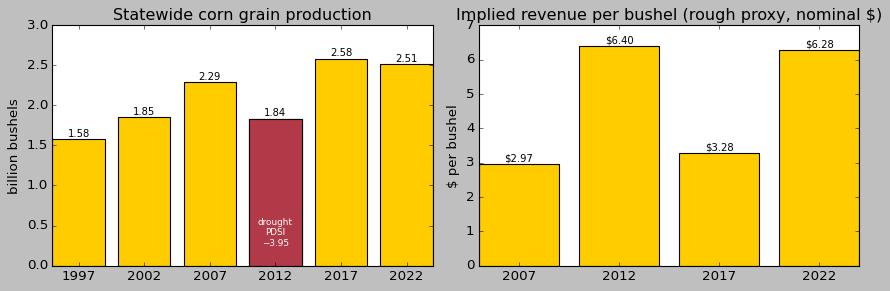

In [23]:
CORN = '#ffcc00'

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].bar(summary.index.astype(str), summary["grain (bn bu)"], color=CORN)
ax[0].bar("2012", summary.loc[2012, "grain (bn bu)"], color="#B23A48")  # drought year override
ax[0].set(title="Statewide corn grain production", ylabel="billion bushels")
for x, v in zip(summary.index.astype(str), summary["grain (bn bu)"]):
    ax[0].text(x, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)
ax[0].text("2012", 0.25, "drought\nPDSI\n−3.95", ha="center", color="white", fontsize=8)

ax[1].bar(econ.index.astype(str), econ["sales per bushel produced ($)"], color=CORN)
ax[1].set(title="Implied revenue per bushel (rough proxy, nominal $)", ylabel="$ per bushel")
for x, v in zip(econ.index.astype(str), econ["sales per bushel produced ($)"]):
    ax[1].text(x, v + 0.08, f"${v:.2f}", ha="center", fontsize=9)

plt.tight_layout();
plt.show();

2012 is the visible dip in production and coincides with the price jump.

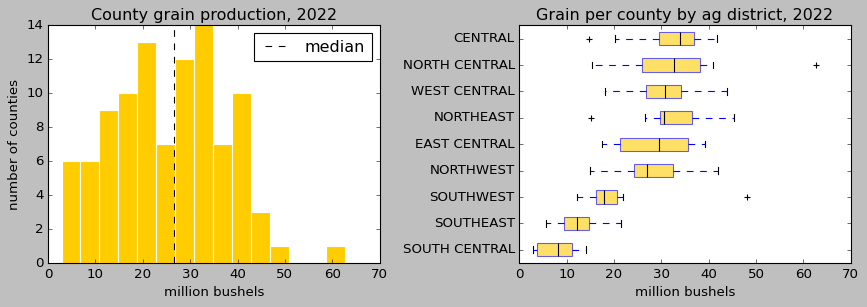

In [26]:
CORN = '#ffcc00' # Defining a color for 'CORN'

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(y22["grain_bu"] / 1e6, bins=15, color=CORN, edgecolor="white")
ax[0].axvline(y22["grain_bu"].median() / 1e6, color="k", ls="--", lw=1, label="median")
ax[0].set(title="County grain production, 2022", xlabel="million bushels", ylabel="number of counties")
ax[0].legend()

order = y22.groupby("ag_district")["grain_bu"].median().sort_values().index
ax[1].boxplot([y22.loc[y22["ag_district"] == d, "grain_bu"] / 1e6 for d in order],
               vert=False, patch_artist=True,
               boxprops=dict(facecolor=CORN, alpha=0.6), medianprops=dict(color="k"))
ax[1].set_yticks(range(1, len(order) + 1), labels=order)
ax[1].set(title="Grain per county by ag district, 2022", xlabel="million bushels")
plt.tight_layout();
plt.show();

County output is spread widely — from about 3 to 63 M bu, with most counties between 15 and 40 M bu and Kossuth as a clear outlier at the top; the three southern districts (South Central, Southeast, Southwest) sit well below the rest.

### Used groupby

In [25]:
by_district = (y22.groupby("ag_district")
    .agg(counties=("county", "count"),
         grain_total=("grain_bu", "sum"),
         grain_mean=("grain_bu", "mean"),
         grain_median=("grain_bu", "median"),
         grain_max=("grain_bu", "max"),
         sales_total=("sales_usd", "sum"),
         farms=("operations_with_sales", "sum"))
    .assign(**{"share_of_state_%": lambda d: d["grain_total"] / d["grain_total"].sum() * 100,
               "sales_per_farm":   lambda d: d["sales_total"] / d["farms"]})
    .sort_values("grain_total", ascending=False))
by_district

,counties,grain_total,grain_mean,grain_median,grain_max,sales_total,farms,share_of_state_%,sales_per_farm
ag_district,,,,,,,,,
CENTRAL,12,382555262.0,3.187961e+07,33971096.5,41806628.0,2.383980e+09,5723.0,15.232239,416561.244103
NORTH CENTRAL,11,369753958.0,3.361400e+07,32775290.0,62768119.0,2.313432e+09,5354.0,14.722528,432094.135226
WEST CENTRAL,12,365335300.0,3.044461e+07,30701249.5,43904981.0,2.324554e+09,5820.0,14.546590,399407.903780
NORTHEAST,11,356447383.0,3.240431e+07,30661847.0,45458920.0,2.182539e+09,7257.0,14.192699,300749.483258
NORTHWEST,12,339850558.0,2.832088e+07,26963796.0,41935284.0,2.220019e+09,6701.0,13.531862,331296.672138
EAST CENTRAL,10,285255836.0,2.852558e+07,29537002.5,39163157.0,1.738094e+09,5507.0,11.358059,315615.398584
SOUTHWEST,9,187884613.0,2.087607e+07,17899806.0,48082473.0,1.195375e+09,3136.0,7.481019,381178.252551
SOUTHEAST,11,140418011.0,1.276527e+07,12204103.0,21398232.0,8.775390e+08,3603.0,5.591037,243557.868443
SOUTH CENTRAL,11,83983192.0,7.634836e+06,8162546.0,14102010.0,5.284030e+08,2265.0,3.343967,233290.507726


**Interpretation.** Central, North Central, West Central, Northeast and Northwest each account for ≈ 13.5–15 % of state grain; South Central produces only ~3 %. Its average county grows just **7.6 M bu vs. 28–34 M bu** in those five districts, and it has the fewest selling farms (2,265). Because district sizes differ (9–12 counties), the *per-county mean* is a fairer comparison than the total.

## 2.8 2012 Drought effect

### used Pivot table

In [31]:
dist_year = wide.pivot_table(index="ag_district", columns="year", values="grain_bu", aggfunc="sum") / 1e6
dist_year.round(1)

year,1997,2002,2007,2012,2017,2022
ag_district,,,,,,
CENTRAL,243.8,299.2,376.8,302.8,383.3,382.6
EAST CENTRAL,173.1,209.3,265.7,197.9,298.7,285.3
NORTH CENTRAL,234.5,273.2,363.6,277.8,377.2,369.8
NORTHEAST,191.6,228.0,275.8,236.1,347.9,356.4
NORTHWEST,234.7,268.0,328.1,289.4,380.4,339.9
SOUTH CENTRAL,56.8,65.2,69.3,43.9,74.8,84.0
SOUTHEAST,111.1,124.2,147.3,104.3,157.0,140.4
SOUTHWEST,116.5,120.9,136.0,121.2,183.2,187.9
WEST CENTRAL,218.9,263.4,329.6,261.8,381.4,365.3


In [32]:
change = pd.DataFrame({
    "2007→2012 (drought) %": (dist_year[2012] / dist_year[2007] - 1) * 100,
    "2012→2017 (rebound) %": (dist_year[2017] / dist_year[2012] - 1) * 100,
}).sort_values("2007→2012 (drought) %")
change

,2007→2012 (drought) %,2012→2017 (rebound) %
ag_district,,
SOUTH CENTRAL,-36.567541,70.224931
SOUTHEAST,-29.188122,50.489638
EAST CENTRAL,-25.500986,50.934309
NORTH CENTRAL,-23.598420,35.766530
WEST CENTRAL,-20.552827,45.659185
CENTRAL,-19.633874,26.590124
NORTHEAST,-14.401135,47.394865
NORTHWEST,-11.792509,31.441111
SOUTHWEST,-10.872563,51.110103


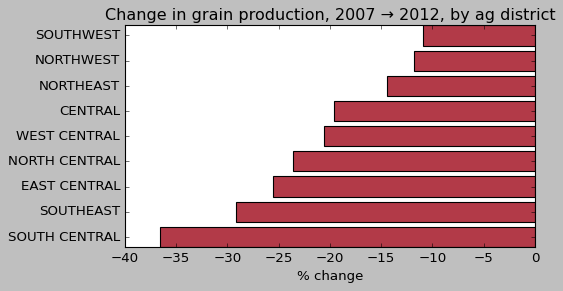

In [34]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(change.index, change["2007→2012 (drought) %"], color="#B23A48")
ax.set(title="Change in grain production, 2007 → 2012, by ag district", xlabel="% change")
ax.axvline(0, color="k", lw=0.8); plt.tight_layout();
plt.show();

## 2.9 Linking corn to weather (census years only)
Weather exists every year but corn census data only every 5 years, so the overlap is **n = 6** (n = 4 for sales). This is exploratory: a table is more honest than a fitted line.

In [28]:
link = summary[["grain (bn bu)", "sales ($ bn)"]].join(econ["sales per bushel produced ($)"]).join(
        wx.set_index("year")[["avg_temp_f", "prcp", "pdsi"]])
link

,grain (bn bu),sales ($ bn),sales per bushel produced ($),avg_temp_f,prcp,pdsi
year,,,,,,
1997,1.581093,NaN,NaN,69.5,2.76,-0.71
2002,1.851276,NaN,NaN,70.9,5.81,0.81
2007,2.292163,6.796491,2.965099,74.2,9.69,3.30
2012,1.835358,11.745805,6.399734,71.0,2.88,-3.95
2017,2.583968,8.463139,3.275249,67.8,3.83,1.89
2022,2.511484,15.763935,6.276741,72.0,3.49,-1.07


In [30]:
link[["grain (bn bu)", "avg_temp_f", "prcp", "pdsi"]].corr().loc["grain (bn bu)"].drop("grain (bn bu)").to_frame("corr with grain (n=6)")

,corr with grain (n=6)
avg_temp_f,0.064190
prcp,0.228979
pdsi,0.444387


**Interpretation.**
* The only census year with a clearly bad August (**2012, PDSI −3.95**) is also the year with the only large fall in production (**−20 %** vs. 2007) *and* the price proxy more than doubled (\$2.97 → \$6.40). That is consistent with drought cutting supply and raising prices.
* Across all six years the correlation of grain with PDSI is only **+0.44**, with rainfall **+0.23**, with temperature **+0.06** — weak, and with n = 6 not statistically meaningful.
* Why not stronger: (1) long-run growth in yields/acres dominates (1997 is the lowest output despite a near-normal August), (2) August is only one slice of the season (pollination is mostly July), and (3) statewide averages hide local conditions. **Takeaway:** weather explains an *outlier year* (2012) better than the general trend.

# Step 3 — Key takeaways, limitations

**Key findings**
1. **Production is up, farms are down.** Grain grew ~59 % (1997–2022) while the number of farms with corn sales dropped ~9 % (2007–2022); sales per farm rose from ≈ \$136k to ≈ \$347k.
2. **Sales follow price more than volume.** 2007→2022 sales +132 % vs. bushels +10 %; implied revenue per bushel flips between ~\$3 and ~\$6.3 in step with known price spikes.
3. **2012 is the outlier year:** driest August in 30 years (PDSI −3.95), grain −20 % statewide, all 9 districts down, then a full rebound by 2017.
4. **Geography:** output is broad-based (top 10 counties ≈ 18 % of grain) but clearly tilted north; silage is a separate, highly skewed livestock-driven pattern.
5. **Weather ↔ corn:** at the census-year level (n = 6) only the 2012 drought stands out; general correlations are weak.

**Limitations**
* Census data come every 5 years → only 6 (or 4) overlap points with weather; no causal claims.
* Weather is a statewide **August-only** average; it ignores the rest of the season and local variation.
* Dollar figures are nominal; sales-per-bushel is a rough proxy.
* `(D)` withheld silage cells (8) are excluded from totals.